In [ ]:
!pip install -q speechbrain soundfile torchaudio scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 43.5 MB/s eta 0:00:00


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import soundfile as sf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve
from torch.utils.data import Dataset, DataLoader
from speechbrain.inference.speaker import EncoderClassifier

In [ ]:
ZIP_DRIVE_PATH = "/content/drive/MyDrive/Capstone Project/dataset/test_dataset.zip"

# 2. Extraction directory on Colab's high-speed local SSD (/content/)
TEST_DATASET_PATH = "/content/test_dataset"

# 3. Model checkpoint paths on Google Drive
MODELS_TO_TEST = {
    "Model No-Aug": "/content/drive/MyDrive/Capstone Project/model checkpoints/No Augmented Checkpoint/ecapa_tdnn_no_aug.pt",
    "Model Rand-Aug": "/content/drive/MyDrive/Capstone Project/model checkpoints/Random Augmented Checkpoint/ecapa_tdnn_finetuned.pt",
    "Model Adp-Aug": "/content/drive/MyDrive/Capstone Project/model checkpoints/Augmented Checkpoint/ecapa_tdnn_finetuned_3.pt"
}

# Extract the dataset from Drive to the local Colab SSD if needed
if not os.path.exists(TEST_DATASET_PATH):
    print("🚀 Đang giải nén test_dataset.zip từ Drive vào SSD Colab...")
    !unzip -q "{ZIP_DRIVE_PATH}" -d /content/
    print("✅ Giải nén hoàn tất vào SSD Colab!")
else:
    print("⚡ Dataset đã sẵn sàng trên SSD Colab.")

# Install runtime dependencies
!pip install -q speechbrain soundfile

# ==============================================================================
# STEP 2: IMPORT LIBRARIES AND CONFIGURE THE GPU
# ==============================================================================


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IS_CUDA = DEVICE.type == 'cuda'

# Colab T4/V100/A100 GPUs support larger batches with FP16 inference
BATCH_SIZE = 128 if IS_CUDA else 32
NUM_WORKERS = 2  # Colab Free provides two CPU cores

print(f"• Device: {DEVICE}")
print(f"• Batch Size: {BATCH_SIZE} | DataLoader Workers: {NUM_WORKERS}")

if IS_CUDA:
    torch.backends.cudnn.benchmark = True

# ==============================================================================
# STEP 3: OPTIMIZED MODEL AND DATASET
# ==============================================================================
class ECAPAFinetuneModel(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.spk_classifier = EncoderClassifier.from_hparams(
            source='speechbrain/spkrec-ecapa-voxceleb',
            run_opts={'device': str(DEVICE)}
        )
        self.backbone = self.spk_classifier.mods.embedding_model
        self.fc = nn.Linear(192, num_classes)

    def extract_embeddings(self, wavs):
        feats = self.spk_classifier.mods.compute_features(wavs)
        lengths = torch.ones(feats.shape[0], device=feats.device)
        feats = self.spk_classifier.mods.mean_var_norm(feats, lengths)
        return self.backbone(feats, lengths=lengths).squeeze(1)

def load_model(model_path):
    if not os.path.exists(model_path):
        print(f"❌ Không tìm thấy checkpoint: {model_path}")
        return None

    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
    state_dict = ckpt.get('model_state_dict', ckpt.get('state_dict', ckpt)) if isinstance(ckpt, dict) else ckpt.state_dict()

    num_classes = state_dict['fc.weight'].size(0) if isinstance(state_dict, dict) and 'fc.weight' in state_dict else 100
    model = ECAPAFinetuneModel(num_classes=num_classes)

    if isinstance(state_dict, dict):
        model.load_state_dict(state_dict, strict=False)
    else:
        model = state_dict

    model.to(DEVICE).eval()
    print(f"-> Load thành công model: {os.path.basename(model_path)}")
    return model

class FastAudioDataset(Dataset):
    """Read 3-second slices from SSD with frame slicing to avoid exhausting RAM."""
    def __init__(self, file_paths, target_samples=48000):
        self.paths = file_paths
        self.target_samples = target_samples

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        try:
            info = sf.info(path)
            total_frames = info.frames

            if total_frames >= self.target_samples:
                start_frame = (total_frames - self.target_samples) // 2
                data, _ = sf.read(path, start=start_frame, stop=start_frame + self.target_samples, dtype='float32')
                wav = torch.from_numpy(data)
            else:
                data, _ = sf.read(path, dtype='float32')
                wav = torch.from_numpy(data)
                wav = F.pad(wav, (0, self.target_samples - len(wav)))

            if wav.ndim > 1:
                wav = wav.mean(dim=-1)

            return wav, idx
        except Exception:
            return torch.zeros(self.target_samples, dtype=torch.float32), idx

def extract_embeddings_fast(file_paths, model):
    loader = DataLoader(
        FastAudioDataset(file_paths),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=IS_CUDA,
        persistent_workers=(NUM_WORKERS > 0)
    )

    embs = torch.zeros((len(file_paths), 192), dtype=torch.float32)

    with torch.no_grad():
        for wavs, idxs in loader:
            wavs = wavs.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=IS_CUDA):
                raw_embs = model.extract_embeddings(wavs)
                norm_embs = F.normalize(raw_embs, p=2, dim=1)
            embs[idxs] = norm_embs.float().cpu()

    if IS_CUDA:
        torch.cuda.empty_cache()
    return embs

# ==============================================================================


# ==============================================================================
# STEP 5: METRICS AND VISUALIZATION
# ==============================================================================
def compute_metrics(labels, scores, p_target=0.01):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[idx] + fnr[idx]) / 2.0 * 100
    dcf = fnr * p_target + fpr * (1 - p_target)
    min_dcf = np.min(dcf) / min(p_target, 1 - p_target)
    return eer, min_dcf, thresholds[idx], fpr, tpr

def plot_models_evaluation(all_results):
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)
    df_res = pd.DataFrame(all_results)

    # 1. EER Bar Plot
    ax1 = axes[0]
    sns.barplot(data=df_res, x='Model', y='EER_val', ax=ax1, palette='Set2')
    ax1.set_title("1. So sánh EER (%)", fontweight="bold")
    ax1.set_ylabel("EER (%)")
    for p in ax1.patches:
        if p.get_height() > 0:
            ax1.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

    # 2. DET Curve
    ax2 = axes[1]
    for row in all_results:
        fnr = 1 - row['tpr']
        valid = (row['fpr'] > 0) & (fnr > 0)
        ax2.plot(row['fpr'][valid] * 100, fnr[valid] * 100, linewidth=2, label=f"{row['Model']} ({row['EER_val']:.2f}%)")
    ax2.set_xscale("log"); ax2.set_yscale("log")
    ax2.set_title("2. DET Curve (Log Scale)", fontweight="bold")
    ax2.legend(loc="upper right")

    # 3. Density Plot
    ax3 = axes[2]
    best_res = df_res.sort_values('EER_val').iloc[0]
    sns.kdeplot(best_res['scores'][best_res['labels'] == 1], ax=ax3, fill=True, color="#2ecc71", label="Target")
    sns.kdeplot(best_res['scores'][best_res['labels'] == 0], ax=ax3, fill=True, color="#e74c3c", label="Non-Target")
    ax3.axvline(x=best_res['threshold'], color="#34495e", linestyle="--", label=f"Thresh ({best_res['threshold']:.4f})")
    ax3.set_title(f"3. Density ({best_res['Model']})", fontweight="bold")
    ax3.legend()

    plt.tight_layout()
    plt.savefig("models_evaluation_results.png", dpi=300)
    print("\n-> Đã lưu biểu đồ tại: models_evaluation_results.png")
    plt.show()

# ==============================================================================
# MAIN PIPELINE EXECUTION

### Test 1: Simple Balenced Pairs

In [ ]:
# STEP 4: CREATE BALANCED PAIRS (PAIR COUNT * 2 = FILE COUNT)
# ==============================================================================
def create_balanced_trials(base_path, seed=42):
    random.seed(seed)
    sub_dirs = [os.path.join(base_path, d) for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    if not sub_dirs: sub_dirs = [base_path]

    spk_sets = [{os.path.basename(os.path.dirname(p)) for p in glob.glob(os.path.join(sd, '**/*.wav'), recursive=True)} for sd in sub_dirs]
    common_speakers = sorted(list(set.intersection(*spk_sets))) if spk_sets else []

    spk_map = {}
    for sd in sub_dirs:
        folder = os.path.basename(sd)
        for spk in common_speakers:
            wavs = glob.glob(os.path.join(sd, spk, '*.wav'))
            if len(wavs) >= 2:
                spk_map[f"{folder}_{spk}"] = wavs

    all_files, file2idx, spk_to_idxs = [], {}, {}
    for spk, flist in spk_map.items():
        spk_to_idxs[spk] = []
        for f in flist:
            if f not in file2idx:
                file2idx[f] = len(all_files)
                all_files.append(f)
            spk_to_idxs[spk].append(file2idx[f])

    total_files = len(all_files)
    # Invariant: pair count multiplied by two equals the file count
    target_total_pairs = total_files // 2
    target_pos = target_total_pairs // 2
    target_neg = target_total_pairs - target_pos

    pairs, labels, used = [], [], set()
    speakers = list(spk_to_idxs.keys())

    # Positive Pairs
    valid_pos_spks = [s for s in speakers if len(spk_to_idxs[s]) >= 2]
    attempts = 0
    while len(pairs) < target_pos and attempts < target_pos * 20:
        attempts += 1
        spk = random.choice(valid_pos_spks)
        i1, i2 = random.sample(spk_to_idxs[spk], 2)
        key = tuple(sorted((i1, i2)))
        if key not in used:
            used.add(key)
            pairs.append((i1, i2))
            labels.append(1)

    # Negative Pairs
    attempts = 0
    while len(labels) < (target_pos + target_neg) and attempts < target_neg * 20:
        attempts += 1
        s1, s2 = random.sample(speakers, 2)
        i1 = random.choice(spk_to_idxs[s1])
        i2 = random.choice(spk_to_idxs[s2])
        key = tuple(sorted((i1, i2)))
        if key not in used:
            used.add(key)
            pairs.append((i1, i2))
            labels.append(0)

    print(f"🔍 Quét xong {len(common_speakers)} ID chung | Tổng {total_files} file .wav trên SSD Colab")
    print(f"⚡ Đã khởi tạo thành công {len(labels)} pairs ({labels.count(1)} Pos, {labels.count(0)} Neg).")
    return all_files, np.array(pairs), np.array(labels)

🚀 Đang giải nén test_dataset.zip từ Drive vào SSD Colab...
✅ Giải nén hoàn tất vào SSD Colab!
• Device: cuda
• Batch Size: 128 | DataLoader Workers: 2

   BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH TRÊN COLAB SSD
🔍 Quét xong 126 ID chung | Tổng 33975 file .wav trên SSD Colab
⚡ Đã khởi tạo thành công 16987 pairs (8493 Pos, 8494 Neg).

==================== [ ĐÁNH GIÁ: Model No-Aug ] ====================


INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


hyperparams.yaml:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


embedding_model.ckpt: reconstructing file:   0%|          |  0.00B / 83.3MB            

...

-> Load thành công model: ecapa_tdnn_finetuned.pt

==================== [ ĐÁNH GIÁ: Model Adp-Aug ] ====================


INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


-> Load thành công model: ecapa_tdnn_finetuned_3.pt

                          BẢNG BÁO CÁO KẾT QUẢ
         Model  Num Files  Num Trials EER (%) minDCF Threshold @ EER Mean Cos (Pos) Mean Cos (Neg)
  Model No-Aug      33975       16987  19.28% 0.9073          0.1020         0.2790         0.0281
Model Rand-Aug      33975       16987  20.45% 0.9544          0.1431         0.3048         0.0701
 Model Adp-Aug      33975       16987  19.19% 0.9299          0.1012         0.2776         0.0265


/tmp/ipykernel_546/3315592703.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_res, x='Model', y='EER_val', ax=ax1, palette='Set2')



-> Đã lưu biểu đồ tại: models_evaluation_results.png


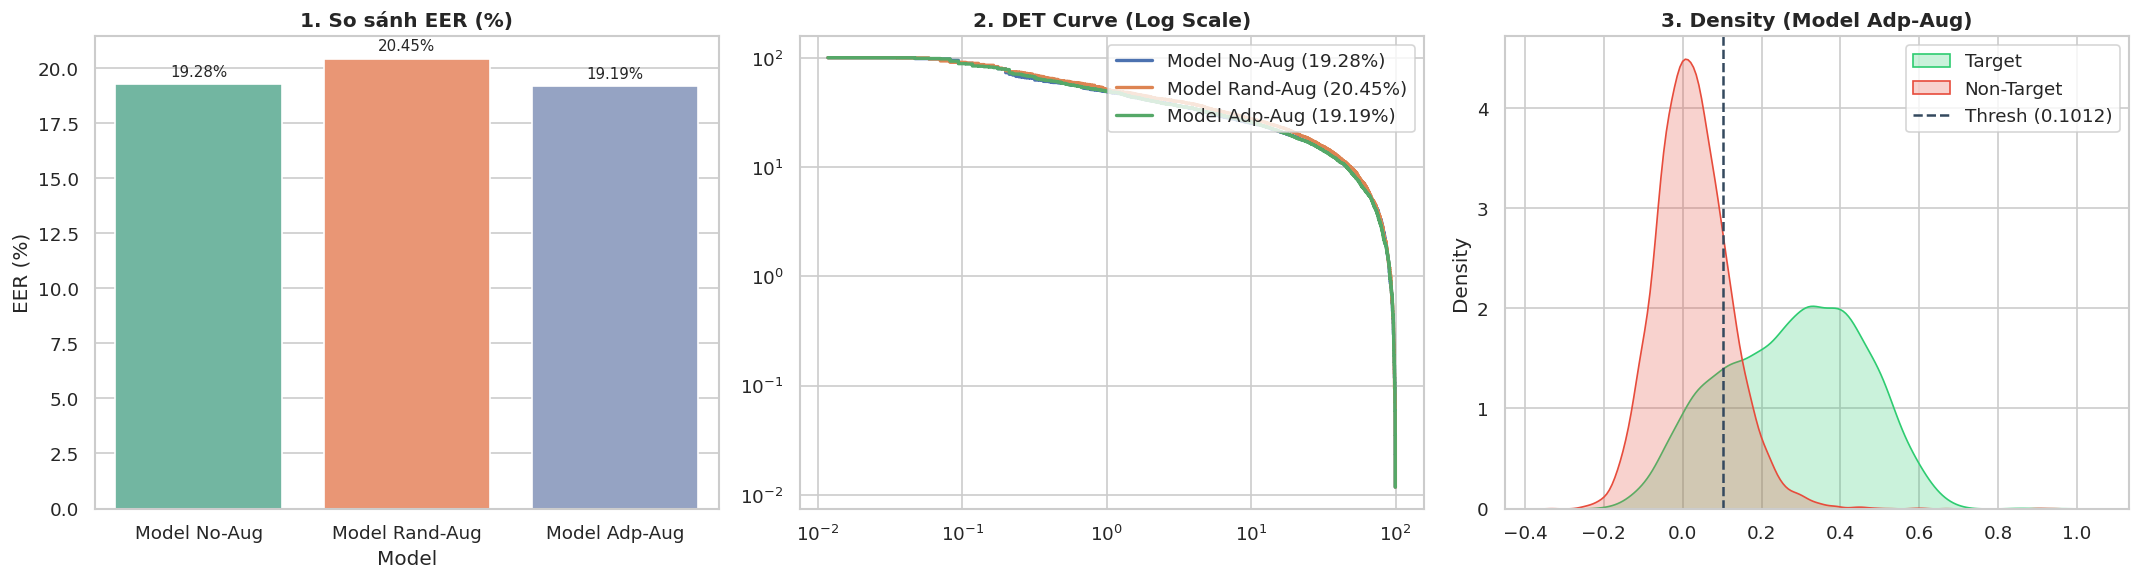

In [ ]:
summary_table, all_plot_data = [], []
print("\n" + "="*75 + "\n   BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH TRÊN COLAB SSD\n" + "="*75)

files, pairs, labels = create_balanced_trials(TEST_DATASET_PATH)

for model_name, model_path in MODELS_TO_TEST.items():
    print(f"\n==================== [ ĐÁNH GIÁ: {model_name} ] ====================")
    model = load_model(model_path)
    if model is None:
        continue

    embs = extract_embeddings_fast(files, model)

    # Compute cosine distance on the GPU to avoid transferring embeddings to CPU
    p1 = torch.tensor(pairs[:, 0], device=DEVICE)
    p2 = torch.tensor(pairs[:, 1], device=DEVICE)
    embs_gpu = embs.to(DEVICE)

    with torch.no_grad():
        scores = torch.sum(embs_gpu[p1] * embs_gpu[p2], dim=1).cpu().numpy()

    eer, min_dcf, thresh, fpr, tpr = compute_metrics(labels, scores)

    summary_table.append({
        'Model': model_name,
        'Num Files': len(files),
        'Num Trials': len(labels),
        'EER (%)': f"{eer:.2f}%",
        'minDCF': f"{min_dcf:.4f}",
        'Threshold @ EER': f"{thresh:.4f}",
        'Mean Cos (Pos)': f"{scores[labels==1].mean():.4f}",
        'Mean Cos (Neg)': f"{scores[labels==0].mean():.4f}"
    })

    all_plot_data.append({
        'Model': model_name, 'EER_val': eer, 'min_dcf': min_dcf,
        'threshold': thresh, 'fpr': fpr, 'tpr': tpr, 'scores': scores, 'labels': labels
    })

    del model, embs, embs_gpu
    if IS_CUDA:
        torch.cuda.empty_cache()

print("\n" + "="*80 + "\n                          BẢNG BÁO CÁO KẾT QUẢ\n" + "="*80)
print(pd.DataFrame(summary_table).to_string(index=False))

if all_plot_data:
    plot_models_evaluation(all_plot_data)


### Test 2: Hard Pairs 1

In [ ]:
def create_balanced_trials(base_path, seed=42):
    random.seed(seed)
    sub_dirs = [os.path.join(base_path, d) for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    if not sub_dirs: sub_dirs = [base_path]

    # Scan files and group them by folder/subdomain
    spk_sets = [{os.path.basename(os.path.dirname(p)) for p in glob.glob(os.path.join(sd, '**/*.wav'), recursive=True)} for sd in sub_dirs]
    common_speakers = sorted(list(set.intersection(*spk_sets))) if spk_sets else []

    spk_map = {}
    folder_to_spks = {}  # Track speakers within each subdirectory (domain/environment)

    for sd in sub_dirs:
        folder = os.path.basename(sd)
        folder_to_spks[folder] = []
        for spk in common_speakers:
            wavs = glob.glob(os.path.join(sd, spk, '*.wav'))
            if len(wavs) >= 2:
                spk_id = f"{folder}_{spk}"
                spk_map[spk_id] = wavs
                folder_to_spks[folder].append(spk_id)

    all_files, file2idx, spk_to_idxs = [], {}, {}
    for spk, flist in spk_map.items():
        spk_to_idxs[spk] = []
        for f in flist:
            if f not in file2idx:
                file2idx[f] = len(all_files)
                all_files.append(f)
            spk_to_idxs[spk].append(file2idx[f])

    total_files = len(all_files)
    # Constraint: pair count multiplied by two equals the file count
    target_total_pairs = total_files // 2
    target_pos = target_total_pairs // 2
    target_neg = target_total_pairs - target_pos

    pairs, labels, used = [], [], set()
    speakers = list(spk_to_idxs.keys())

    # =========================================================================
    # 1. POSITIVE PAIRS: diversify samples by choosing files at different positions
    # =========================================================================
    valid_pos_spks = [s for s in speakers if len(spk_to_idxs[s]) >= 2]
    attempts = 0
    while len(pairs) < target_pos and attempts < target_pos * 20:
        attempts += 1
        spk = random.choice(valid_pos_spks)
        i1, i2 = random.sample(spk_to_idxs[spk], 2)
        key = tuple(sorted((i1, i2)))
        if key not in used:
            used.add(key)
            pairs.append((i1, i2))
            labels.append(1)

    # =========================================================================
    # 2. HARD NEGATIVE PAIRS: prefer different speakers from the same folder
    # Similar environments and channel noise make these pairs harder to separate
    # =========================================================================
    # Keep folders containing at least two distinct speakers
    valid_folders = [f for f, spks in folder_to_spks.items() if len(spks) >= 2]
    attempts = 0

    while len(labels) < (target_pos + target_neg) and attempts < target_neg * 30:
        attempts += 1
        # Draw 80% hard negatives from one environment and 20% random negatives
        if valid_folders and random.random() < 0.8:
            chosen_folder = random.choice(valid_folders)
            s1, s2 = random.sample(folder_to_spks[chosen_folder], 2)
        else:
            s1, s2 = random.sample(speakers, 2)

        i1 = random.choice(spk_to_idxs[s1])
        i2 = random.choice(spk_to_idxs[s2])
        key = tuple(sorted((i1, i2)))

        if key not in used:
            used.add(key)
            pairs.append((i1, i2))
            labels.append(0)

    print(f"🔍 Quét xong {len(common_speakers)} ID chung | Tổng {total_files} file .wav")
    print(f"🎯 Đã tạo tập Pairs thử nghiệm mới (Hard Negative): {len(labels)} pairs ({labels.count(1)} Pos, {labels.count(0)} Neg).")
    return all_files, np.array(pairs), np.array(labels)


   BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH TRÊN COLAB SSD
🔍 Quét xong 126 ID chung | Tổng 33975 file .wav
🎯 Đã tạo tập Pairs thử nghiệm mới (Hard Negative): 16987 pairs (8493 Pos, 8494 Neg).

==================== [ ĐÁNH GIÁ: Model No-Aug ] ====================


INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


-> Load thành công model: ecapa_tdnn_no_aug.pt

==================== [ ĐÁNH GIÁ: Model Rand-Aug ] ====================


INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


-> Load thành công model: ecapa_tdnn_finetuned.pt

==================== [ ĐÁNH GIÁ: Model Adp-Aug ] ====================


INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


-> Load thành công model: ecapa_tdnn_finetuned_3.pt

                          BẢNG BÁO CÁO KẾT QUẢ
         Model  Num Files  Num Trials EER (%) minDCF Threshold @ EER Mean Cos (Pos) Mean Cos (Neg)
  Model No-Aug      33975       16987  19.36% 0.7732          0.1025         0.2790         0.0265
Model Rand-Aug      33975       16987  20.55% 0.8034          0.1439         0.3048         0.0701
 Model Adp-Aug      33975       16987  19.21% 0.7626          0.1012         0.2776         0.0249


/tmp/ipykernel_546/3315592703.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_res, x='Model', y='EER_val', ax=ax1, palette='Set2')



-> Đã lưu biểu đồ tại: models_evaluation_results.png


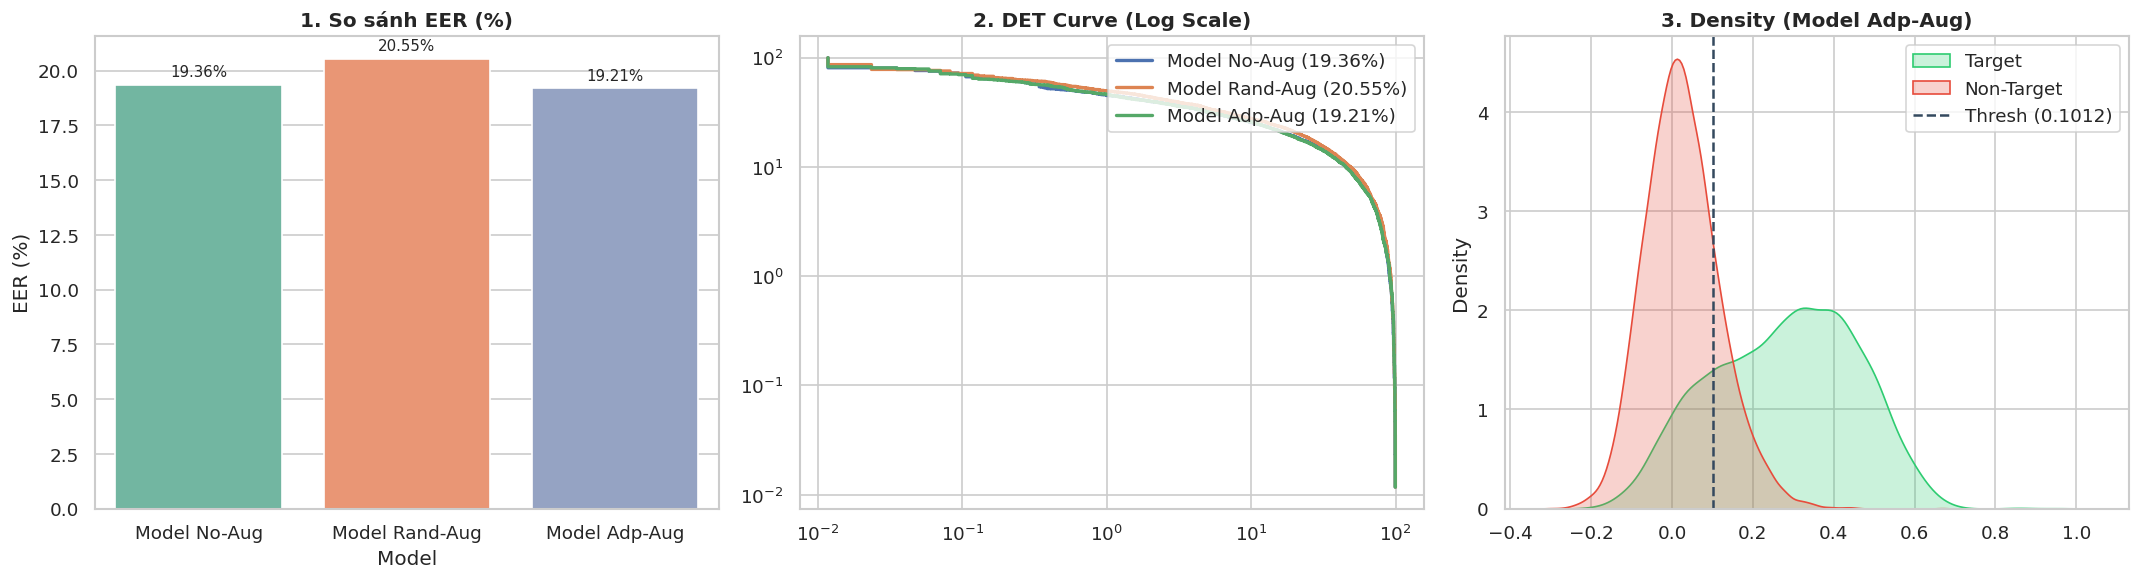

In [ ]:
# ==============================================================================
summary_table, all_plot_data = [], []
print("\n" + "="*75 + "\n   BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH TRÊN COLAB SSD\n" + "="*75)

files, pairs, labels = create_balanced_trials(TEST_DATASET_PATH)

for model_name, model_path in MODELS_TO_TEST.items():
    print(f"\n==================== [ ĐÁNH GIÁ: {model_name} ] ====================")
    model = load_model(model_path)
    if model is None:
        continue

    embs = extract_embeddings_fast(files, model)

    # Compute cosine distance on the GPU to avoid transferring embeddings to CPU
    p1 = torch.tensor(pairs[:, 0], device=DEVICE)
    p2 = torch.tensor(pairs[:, 1], device=DEVICE)
    embs_gpu = embs.to(DEVICE)

    with torch.no_grad():
        scores = torch.sum(embs_gpu[p1] * embs_gpu[p2], dim=1).cpu().numpy()

    eer, min_dcf, thresh, fpr, tpr = compute_metrics(labels, scores)

    summary_table.append({
        'Model': model_name,
        'Num Files': len(files),
        'Num Trials': len(labels),
        'EER (%)': f"{eer:.2f}%",
        'minDCF': f"{min_dcf:.4f}",
        'Threshold @ EER': f"{thresh:.4f}",
        'Mean Cos (Pos)': f"{scores[labels==1].mean():.4f}",
        'Mean Cos (Neg)': f"{scores[labels==0].mean():.4f}"
    })

    all_plot_data.append({
        'Model': model_name, 'EER_val': eer, 'min_dcf': min_dcf,
        'threshold': thresh, 'fpr': fpr, 'tpr': tpr, 'scores': scores, 'labels': labels
    })

    del model, embs, embs_gpu
    if IS_CUDA:
        torch.cuda.empty_cache()

print("\n" + "="*80 + "\n                          BẢNG BÁO CÁO KẾT QUẢ\n" + "="*80)
print(pd.DataFrame(summary_table).to_string(index=False))

if all_plot_data:
    plot_models_evaluation(all_plot_data)

### Test 3: Hard Pairs 2

In [ ]:
def create_balanced_trials(base_path, seed=42):
    random.seed(seed)
    sub_dirs = [os.path.join(base_path, d) for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

    # Group files as speaker_id -> {folder_1: [files], folder_2: [files]}
    spk_domain_map = {}
    all_files, file2idx = [], {}

    for sd in sub_dirs:
        folder = os.path.basename(sd)
        spks = [os.path.basename(os.path.dirname(p)) for p in glob.glob(os.path.join(sd, '**/*.wav'), recursive=True)]
        for spk in set(spks):
            wavs = glob.glob(os.path.join(sd, spk, '*.wav'))
            if wavs:
                if spk not in spk_domain_map: spk_domain_map[spk] = {}
                spk_domain_map[spk][folder] = []
                for f in wavs:
                    if f not in file2idx:
                        file2idx[f] = len(all_files)
                        all_files.append(f)
                    spk_domain_map[spk][folder].append(file2idx[f])

    total_files = len(all_files)
    target_total_pairs = total_files // 2
    target_pos = target_total_pairs // 2
    target_neg = target_total_pairs - target_pos

    pairs, labels, used = [], [], set()

    # Retain speakers represented in at least two folders/domains
    cross_spks = [s for s, domains in spk_domain_map.items() if len(domains) >= 2]

    # 1. POSITIVE: sample two domains for the same speaker
    attempts = 0
    while len(pairs) < target_pos and attempts < target_pos * 30:
        attempts += 1
        spk = random.choice(cross_spks)
        d1, d2 = random.sample(list(spk_domain_map[spk].keys()), 2)
        i1 = random.choice(spk_domain_map[spk][d1])
        i2 = random.choice(spk_domain_map[spk][d2])
        key = tuple(sorted((i1, i2)))
        if key not in used:
            used.add(key); pairs.append((i1, i2)); labels.append(1)

    # 2. NEGATIVE: sample utterances from different speakers
    all_spk_list = list(spk_domain_map.keys())
    attempts = 0
    while len(labels) < (target_pos + target_neg) and attempts < target_neg * 30:
        attempts += 1
        s1, s2 = random.sample(all_spk_list, 2)
        d1 = random.choice(list(spk_domain_map[s1].keys()))
        d2 = random.choice(list(spk_domain_map[s2].keys()))
        i1 = random.choice(spk_domain_map[s1][d1])
        i2 = random.choice(spk_domain_map[s2][d2])
        key = tuple(sorted((i1, i2)))
        if key not in used:
            used.add(key); pairs.append((i1, i2)); labels.append(0)

    print(f"🎯 Cross-Domain Trials: {len(labels)} pairs ({labels.count(1)} Pos, {labels.count(0)} Neg).")
    return all_files, np.array(pairs), np.array(labels)


   BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH TRÊN COLAB SSD
🎯 Cross-Domain Trials: 17004 pairs (8502 Pos, 8502 Neg).

==================== [ ĐÁNH GIÁ: Model No-Aug ] ====================


INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


-> Load thành công model: ecapa_tdnn_no_aug.pt

==================== [ ĐÁNH GIÁ: Model Rand-Aug ] ====================


INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


-> Load thành công model: ecapa_tdnn_finetuned.pt

==================== [ ĐÁNH GIÁ: Model Adp-Aug ] ====================


INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


-> Load thành công model: ecapa_tdnn_finetuned_3.pt

                          BẢNG BÁO CÁO KẾT QUẢ
         Model  Num Files  Num Trials EER (%) minDCF Threshold @ EER Mean Cos (Pos) Mean Cos (Neg)
  Model No-Aug      34008       17004  18.92% 0.7477          0.1017         0.2969         0.0254
Model Rand-Aug      34008       17004  19.88% 0.7422          0.1435         0.3204         0.0693
 Model Adp-Aug      34008       17004  18.64% 0.7656          0.1007         0.2958         0.0236


/tmp/ipykernel_546/3315592703.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_res, x='Model', y='EER_val', ax=ax1, palette='Set2')



-> Đã lưu biểu đồ tại: models_evaluation_results.png


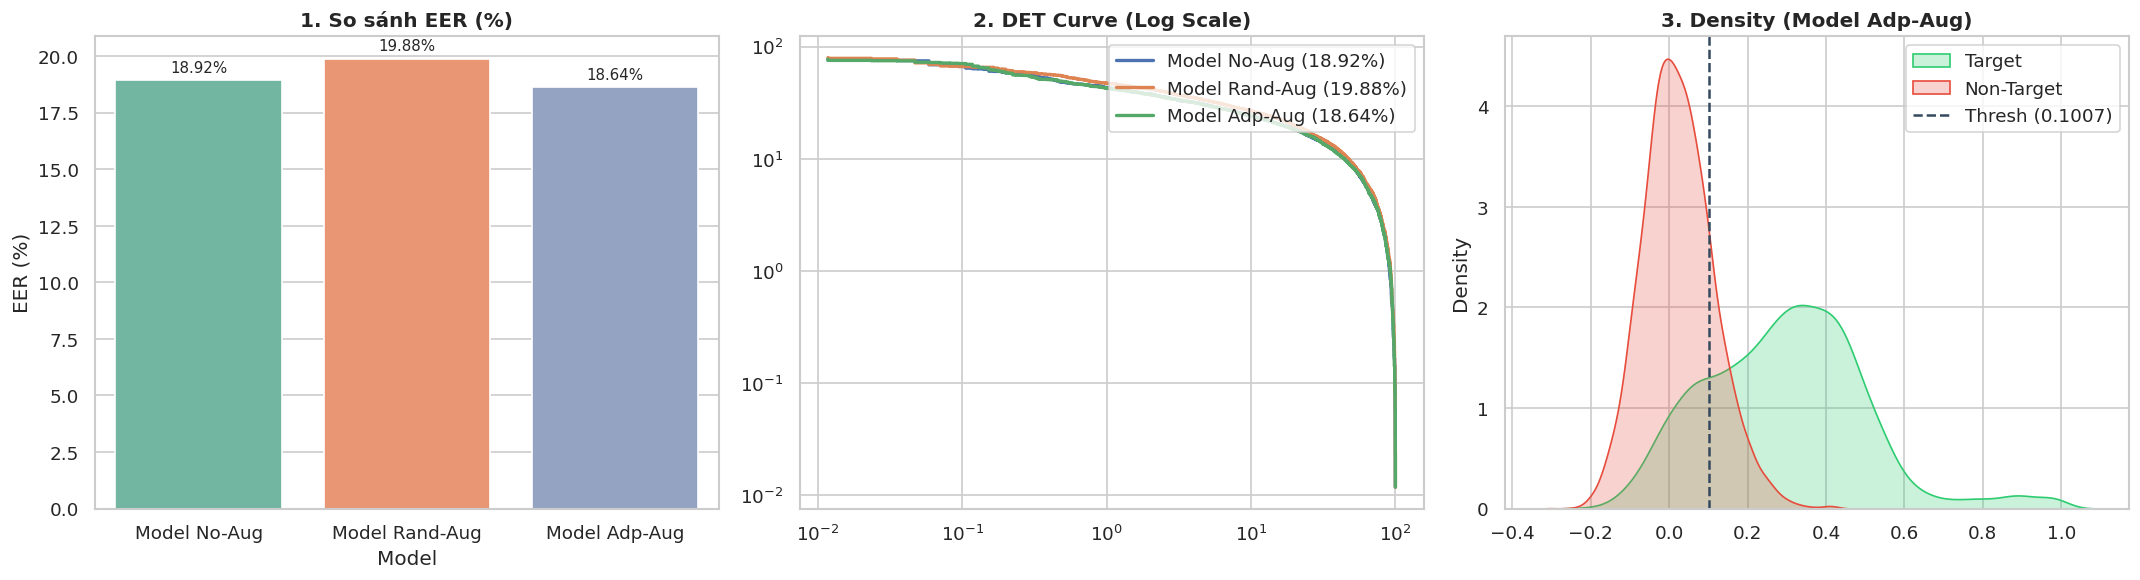

In [ ]:
# ==============================================================================
summary_table, all_plot_data = [], []
print("\n" + "="*75 + "\n   BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH TRÊN COLAB SSD\n" + "="*75)

files, pairs, labels = create_balanced_trials(TEST_DATASET_PATH)

for model_name, model_path in MODELS_TO_TEST.items():
    print(f"\n==================== [ ĐÁNH GIÁ: {model_name} ] ====================")
    model = load_model(model_path)
    if model is None:
        continue

    embs = extract_embeddings_fast(files, model)

    # Compute cosine distance on the GPU to avoid transferring embeddings to CPU
    p1 = torch.tensor(pairs[:, 0], device=DEVICE)
    p2 = torch.tensor(pairs[:, 1], device=DEVICE)
    embs_gpu = embs.to(DEVICE)

    with torch.no_grad():
        scores = torch.sum(embs_gpu[p1] * embs_gpu[p2], dim=1).cpu().numpy()

    eer, min_dcf, thresh, fpr, tpr = compute_metrics(labels, scores)

    summary_table.append({
        'Model': model_name,
        'Num Files': len(files),
        'Num Trials': len(labels),
        'EER (%)': f"{eer:.2f}%",
        'minDCF': f"{min_dcf:.4f}",
        'Threshold @ EER': f"{thresh:.4f}",
        'Mean Cos (Pos)': f"{scores[labels==1].mean():.4f}",
        'Mean Cos (Neg)': f"{scores[labels==0].mean():.4f}"
    })

    all_plot_data.append({
        'Model': model_name, 'EER_val': eer, 'min_dcf': min_dcf,
        'threshold': thresh, 'fpr': fpr, 'tpr': tpr, 'scores': scores, 'labels': labels
    })

    del model, embs, embs_gpu
    if IS_CUDA:
        torch.cuda.empty_cache()

print("\n" + "="*80 + "\n                          BẢNG BÁO CÁO KẾT QUẢ\n" + "="*80)
print(pd.DataFrame(summary_table).to_string(index=False))

if all_plot_data:
    plot_models_evaluation(all_plot_data)